In [1]:
import sys
import os
import warnings
from datetime import datetime, timezone
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
import json
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from scipy.stats import norm

current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.insert(0, str(parent_dir))
from lib import *

MODEL_PATH=parent_dir / 'models' 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

In [36]:
example_ticker = "KXBTC15M-26APR270400-00"
lookback_minutes = 60
series, event_dt = parse_kalshi_15m_event_ticker(example_ticker)
dt_only = get_ticker_datetime(example_ticker)
crypto_at = datetime.now(timezone.utc)
df_api = get_market_data_from_api(series, crypto_at, lookback_minutes)

In [37]:
df_api = df_api.set_index('datetime')
df_api.index = df_api.index.tz_convert('America/Chicago')
df_api.sort_index(inplace=True)
print(len(df_api))

60


In [38]:
df_crypto = get_crypto_past_minutes(series, crypto_at, lookback_minutes)

In [39]:
df_crypto['datetime'] = pd.to_datetime(df_crypto['datetime'])
df_crypto['datetime'] = df_crypto['datetime'].dt.tz_convert('America/Chicago')
df_crypto['datetime'] = df_crypto['datetime'].dt.floor('min')
df_crypto = df_crypto.set_index('datetime')
filter_timestamp = df_crypto[df_crypto.index.minute.isin([0,15,30,45])].index[0]
df_crypto = df_crypto[df_crypto.index >= filter_timestamp]
df_crypto.head()

,open,high,low,close,tick_count
datetime,,,,,
2026-04-30 07:15:00-05:00,76092.47,76130.68,76092.47,76126.32,58
2026-04-30 07:16:00-05:00,76121.46,76151.94,76118.41,76129.20,40
2026-04-30 07:17:00-05:00,76129.20,76129.20,76129.20,76129.20,0
2026-04-30 07:18:00-05:00,76172.19,76172.19,76172.19,76172.19,0
2026-04-30 07:19:00-05:00,76195.45,76195.45,76189.69,76189.69,0


In [40]:
df_merged = df_crypto.join(df_api, how='left')
df_merged = df_merged.dropna()
df_merged.head(60)

,open,high,low,close,tick_count,ticker,volume_fp,open_interest_fp,floor_strike,end_period_ts,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-30 07:15:00-05:00,76092.47,76130.68,76092.47,76126.32,58,KXBTC15M-26APR300815-15,5052.50,58284.01,76033.74,1.777551e+09,0.995,1.000,0.995,1.000,0.994,0.999,0.994,0.999,0.006,0.001,0.006,0.001,0.005,0.000,0.005,0.000
2026-04-30 07:16:00-05:00,76121.46,76151.94,76118.41,76129.20,40,KXBTC15M-26APR300830-30,20861.08,14878.17,76107.71,1.777551e+09,0.999,0.999,0.500,0.600,0.000,0.620,0.000,0.590,1.000,0.380,1.000,0.410,0.001,0.001,0.500,0.400
2026-04-30 07:17:00-05:00,76129.20,76129.20,76129.20,76129.20,0,KXBTC15M-26APR300830-30,18002.57,24576.35,76107.71,1.777551e+09,0.600,0.780,0.580,0.760,0.590,0.770,0.570,0.750,0.410,0.230,0.430,0.250,0.400,0.220,0.420,0.240
2026-04-30 07:18:00-05:00,76172.19,76172.19,76172.19,76172.19,0,KXBTC15M-26APR300830-30,12983.74,33710.25,76107.71,1.777551e+09,0.760,0.830,0.760,0.790,0.750,0.810,0.750,0.780,0.250,0.190,0.250,0.220,0.240,0.170,0.240,0.210
2026-04-30 07:19:00-05:00,76195.45,76195.45,76189.69,76189.69,0,KXBTC15M-26APR300830-30,9437.88,36853.21,76107.71,1.777552e+09,0.790,0.840,0.750,0.840,0.780,0.820,0.740,0.820,0.220,0.180,0.260,0.180,0.210,0.160,0.250,0.160
2026-04-30 07:20:00-05:00,76196.71,76197.06,76196.71,76197.06,0,KXBTC15M-26APR300830-30,5262.66,38097.10,76107.71,1.777552e+09,0.840,0.890,0.820,0.890,0.820,0.880,0.810,0.880,0.180,0.120,0.190,0.120,0.160,0.110,0.180,0.110
2026-04-30 07:21:00-05:00,76204.45,76204.45,76194.12,76194.12,0,KXBTC15M-26APR300830-30,10699.96,42828.88,76107.71,1.777552e+09,0.890,0.934,0.880,0.904,0.880,0.933,0.870,0.902,0.120,0.067,0.130,0.098,0.110,0.066,0.120,0.096
2026-04-30 07:22:00-05:00,76219.50,76221.95,76219.50,76221.95,0,KXBTC15M-26APR300830-30,10213.92,47484.37,76107.71,1.777552e+09,0.904,0.960,0.900,0.947,0.902,0.954,0.890,0.946,0.098,0.046,0.110,0.054,0.096,0.040,0.100,0.053
2026-04-30 07:23:00-05:00,76226.94,76249.15,76225.42,76240.68,34,KXBTC15M-26APR300830-30,9005.21,52606.75,76107.71,1.777552e+09,0.947,0.978,0.946,0.969,0.946,0.972,0.942,0.962,0.054,0.028,0.058,0.038,0.053,0.022,0.054,0.031


In [32]:
def agg_new_df(df):
    result = []
    min_yes = 1
    max_yes = 0
    yes_dist = 0
    min_no = 1
    max_no = 0
    no_dist = 0
    prev_stag = 0
    curr_stag = 0
    open_price=0
    high_price=0
    low_price=2**31
    close_price=0
    tmp_list = []
    for index, row in df.iterrows():
        # print(row)
        curr_stag = index.minute // 15
        min_yes = min(float(row['yes_ask_low_dollar']), min_yes)
        min_no = min(float(row['no_ask_low_dollar']), min_no)
        yes_dist = max(yes_dist, float(row['yes_bid_high_dollar']) - min_yes)
        no_dist = max(no_dist, float(row['no_bid_high_dollar']) - min_no)
        low_price=min(row['low'], low_price)
        high_price=max(row['high'], high_price)
        close_price=row['close']
        if prev_stag != curr_stag:
            result.append(tmp_list)
            tmp_list = []
            start = 0
            min_yes = 1
            max_yes = 0
            yes_dist = 0
            min_no = 1
            max_no = 0
            no_dist = 0
            open_price=row['open']
            high_price=0
            low_price=2**31
            close_price=row['close']
        floor_minute = (index.minute // 15) * 15
        tmp_list = [index.replace(minute=floor_minute, second=0, microsecond=0), 
            round(float(open_price),4),
            round(float(high_price),4),
            round(float(low_price),4),
            round(float(close_price),4),
            round(row['floor_strike'], 4),
            round(min_yes,4), round(yes_dist,4), 
            round(min_no,4), 
            round(no_dist,4)]
        prev_stag = curr_stag
    return result

In [33]:
res = agg_new_df(df_merged)
columns = ['datetime','open', 'high', 'low', 'close', 'floor_strike','min_yes','yes_dist','min_no','no_dist']
df4 = pd.DataFrame(res, columns=columns)
df4 = df4.dropna()
df4.head()

,datetime,open,high,low,close,floor_strike,min_yes,yes_dist,min_no,no_dist
1,2026-04-29 06:45:00-05:00,77560.08,77621.47,77542.67,77586.59,77565.38,0.360,0.631,0.17,0.260
2,2026-04-29 07:00:00-05:00,77593.39,77603.43,77459.23,77476.80,77590.35,0.001,0.250,0.56,0.436


In [34]:
df_merged.head(60)

,open,high,low,close,tick_count,ticker,volume_fp,open_interest_fp,floor_strike,end_period_ts,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-29 06:45:00-05:00,77560.08,77563.91,77558.80,77561.65,11,KXBTC15M-26APR290745-45,1918.63,45622.81,77499.97,1.777463e+09,0.998,1.000,0.992,1.000,0.992,0.999,0.991,0.999,0.008,0.001,0.009,0.001,0.002,0.000,0.008,0.000
2026-04-29 06:46:00-05:00,77567.13,77568.03,77552.99,77555.06,31,KXBTC15M-26APR290800-00,14259.64,10243.25,77565.38,1.777463e+09,0.999,0.999,0.420,0.750,0.000,0.750,0.000,0.740,1.000,0.250,1.000,0.260,0.001,0.001,0.580,0.250
2026-04-29 06:47:00-05:00,77555.06,77562.44,77555.06,77562.44,0,KXBTC15M-26APR290800-00,7966.34,16344.28,77565.38,1.777463e+09,0.750,0.750,0.680,0.730,0.740,0.740,0.670,0.720,0.260,0.260,0.330,0.280,0.250,0.250,0.320,0.270
2026-04-29 06:48:00-05:00,77610.94,77617.65,77610.94,77617.65,0,KXBTC15M-26APR290800-00,24610.34,21637.79,77565.38,1.777463e+09,0.730,0.917,0.690,0.760,0.720,0.914,0.680,0.750,0.280,0.086,0.320,0.250,0.270,0.083,0.310,0.240
2026-04-29 06:49:00-05:00,77619.71,77621.47,77602.10,77604.33,22,KXBTC15M-26APR290800-00,7131.42,23006.27,77565.38,1.777463e+09,0.760,0.760,0.630,0.630,0.750,0.750,0.610,0.620,0.250,0.250,0.390,0.380,0.240,0.240,0.370,0.370
2026-04-29 06:50:00-05:00,77608.05,77608.05,77608.05,77608.05,0,KXBTC15M-26APR290800-00,5802.59,21896.68,77565.38,1.777463e+09,0.630,0.690,0.580,0.580,0.620,0.680,0.570,0.570,0.380,0.320,0.430,0.430,0.370,0.310,0.420,0.420
2026-04-29 06:51:00-05:00,77591.64,77593.03,77591.64,77593.03,0,KXBTC15M-26APR290800-00,5269.75,21154.88,77565.38,1.777463e+09,0.580,0.580,0.410,0.420,0.570,0.570,0.400,0.410,0.430,0.430,0.600,0.590,0.420,0.420,0.590,0.580
2026-04-29 06:52:00-05:00,77551.69,77551.69,77542.67,77549.29,20,KXBTC15M-26APR290800-00,2458.11,20995.93,77565.38,1.777464e+09,0.420,0.420,0.360,0.390,0.410,0.410,0.350,0.380,0.590,0.590,0.650,0.620,0.580,0.580,0.640,0.610
2026-04-29 06:53:00-05:00,77549.29,77549.29,77549.29,77549.29,0,KXBTC15M-26APR290800-00,9897.43,25248.20,77565.38,1.777464e+09,0.390,0.610,0.380,0.590,0.380,0.580,0.370,0.580,0.620,0.420,0.630,0.420,0.610,0.390,0.620,0.410


In [10]:
df4['yes_floor_dist'] = df4['high'] - df4['floor_strike']
df4['no_floor_dist'] = df4['floor_strike'] - df4['low']
df4['vol'] = np.log(df4['close']).diff().rolling(15).std()

<Axes: >

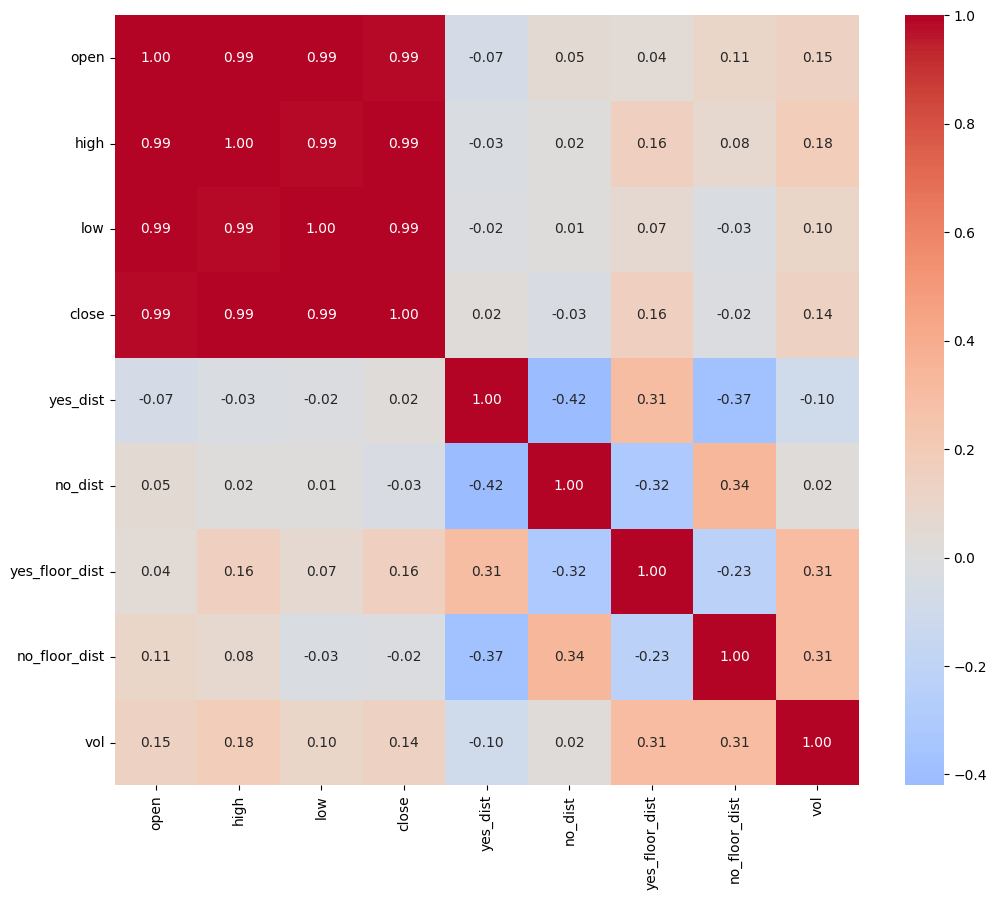

In [11]:
cols = ['open','high','low','close','yes_dist','no_dist','yes_floor_dist','no_floor_dist','vol']
corr_matrix = df4[cols].dropna().corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm', center=0, fmt='.2f')

In [12]:
df4['net_profit'] = np.maximum(df4['yes_dist'], df4['no_dist'])
df4['can_profit'] = (df4['net_profit'] > 0).astype(int)
df4 = df4.set_index('datetime')

0.5092184557438795

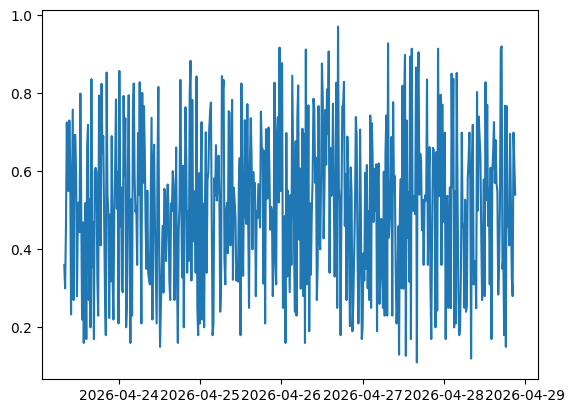

In [24]:
plt.plot(df4.index, df4['yes_dist'])
df4['yes_dist'].mean()

In [19]:
df4['range_1m'] = df4['high'] - df4['low']
df4['price_to_floor'] = (df4['close'] - df4['floor_strike']) / df4['floor_strike']
df4['momentum'] = df4['close'] - df4['open']
df4['sample_vol5'] = df4['close'].rolling(5).std()
df4['sample_vol15'] = df4['close'].rolling(15).std()
df4['vol_ma5'] = df4['close'].rolling(5).mean()
df4['vol_ma15'] = df4['close'].rolling(15).mean()
df4['hour'] = df4.index.hour
df4['minute'] = df4.index.minute

features = [
    'open', 'high', 'low', 'close', 
    'floor_strike', 'vol', 'yes_floor_dist',
    'range_1m', 'price_to_floor', 'momentum', 
    'sample_vol5', 'sample_vol15', 'vol_ma5', 'vol_ma15', 'hour'
]

features_to_lag = ['open', 'high', 'low', 'close', 'vol', 'yes_floor_dist',
                   'floor_strike', 'range_1m', 
                   'price_to_floor', 'momentum', 'sample_vol5', 
                   'sample_vol15', 'vol_ma5', 'vol_ma15']

for col in features_to_lag:
    df4[f'{col}_lag1'] = df4[col].shift(1)

features_lagged = [f'{col}_lag1' for col in features_to_lag] + ['hour', 'minute']

dist_pred = 'yes_dist'
df_clean = df4[features_lagged + [dist_pred]].dropna()
X = df_clean[features_lagged]
y = df_clean[dist_pred]


tscv = TimeSeriesSplit(n_splits=5)

rf_scores = []
gb_scores = []
feature_importances = []


for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # random forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_score = r2_score(y_test, rf_pred)
    rf_scores.append(rf_score)
    
    # GBDT
    gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    gb.fit(X_train, y_train)
    gb_pred = gb.predict(X_test)
    gb_score = r2_score(y_test, gb_pred)
    gb_scores.append(gb_score)
    
    feature_importances.append(rf.feature_importances_)
    
    print(f"Fold {fold+1}: RandomForest={rf_score:.4f}, GBDT={gb_score:.4f}")

print("-"*50)
print(f"RandomForest R²: {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")
print(f"GBDT R²: {np.mean(gb_scores):.4f} (+/- {np.std(gb_scores):.4f})")
print("="*50)

# ranking
importance_df = pd.DataFrame({
    'feature': features_lagged,
    'importance': np.mean(feature_importances, axis=0)
}).sort_values('importance', ascending=False)

print("\nRanking")
print(importance_df)
print("\n")

print("\nFinal Model")

rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,           
    min_samples_split=10,  
    min_samples_leaf=5,   
    random_state=42,
    n_jobs=-1
)

simple_features = ['vol_lag1', 'sample_vol5_lag1','yes_floor_dist_lag1']
X = df_clean[simple_features]
y = df_clean[dist_pred]

rf_final.fit(X, y)
tscv_final = TimeSeriesSplit(n_splits=5)
final_scores = []

for train_idx, test_idx in tscv_final.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    rf_final_cv = RandomForestRegressor(
        n_estimators=100, max_depth=4, min_samples_split=10, 
        min_samples_leaf=5, random_state=42, n_jobs=-1
    )
    rf_final_cv.fit(X_train, y_train)
    score = r2_score(y_test, rf_final_cv.predict(X_test))
    final_scores.append(score)

print(f"Average R²: {np.mean(final_scores):.4f} (+/- {np.std(final_scores):.4f})")

Fold 1: RandomForest=-0.1452, GBDT=-0.3451
Fold 2: RandomForest=-0.0550, GBDT=-0.3078
Fold 3: RandomForest=-0.0453, GBDT=-0.2616
Fold 4: RandomForest=-0.0949, GBDT=-0.7859
Fold 5: RandomForest=-0.1228, GBDT=-0.1486
--------------------------------------------------
RandomForest R²: -0.0927 (+/- 0.0383)
GBDT R²: -0.3698 (+/- 0.2183)

Ranking
                feature  importance
4              vol_lag1    0.101177
10     sample_vol5_lag1    0.092116
5   yes_floor_dist_lag1    0.088620
7         range_1m_lag1    0.085417
13        vol_ma15_lag1    0.069869
11    sample_vol15_lag1    0.067744
8   price_to_floor_lag1    0.066207
9         momentum_lag1    0.060725
3            close_lag1    0.060491
2              low_lag1    0.054487
14                 hour    0.053873
12         vol_ma5_lag1    0.053841
1             high_lag1    0.045756
0             open_lag1    0.034419
6     floor_strike_lag1    0.032768
15               minute    0.032491



Final Model
Average R²: -0.0630 (+/- 0.061

In [68]:
# simple production model dumps
# df4['datetime'] = pd.to_datetime(df4['datetime'])
# df4 = df4.set_index('datetime').sort_index()
features = ['price_to_floor','floor_dist']
df_clean = df4[features + [dist_pred]].dropna()
X = df_clean[features]
y = df_clean[dist_pred]

tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestRegressor(
        n_estimators = 100, max_depth=4,
        min_samples_split=10, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    scores.append(r2_score(y_test, rf.predict(X_test)))

print(f'Average R2 is: {np.mean(scores):.4f} std: {np.std(scores):.4f}')

rf_final = RandomForestRegressor(
    n_estimators=100, max_depth=4,
    min_samples_split=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_final.fit(X, y)
joblib.dump(rf_final, MODEL_PATH / f"{dist_pred + '_model.pkl'}")



Average R2 is: 0.5515 std: 0.0957


['/Users/yingxie/Documents/Git/Quant/Kalshi/btc_15_strategy/models/no_dist_model.pkl']

In [60]:
def find_optimal_window(df, window_sizes=[100, 200, 300, 400, 500, 600, 800, 1000]):
    results = []
    
    for window in window_sizes:
        scores = []
        
        if window + 50 > len(df):
            print(f"Skips {window}")
            results.append({'window_size': window, 'avg_r2': np.nan, 'std_r2': np.nan})
            continue
        
        test_starts = range(window, len(df) - 50, 50)
        
        for test_start in test_starts:
            test_end = test_start + 50
            
            train_start = max(0, test_start - window)
            
            X_train = df.iloc[train_start:test_start][['price_to_floor', 'floor_dist']]
            y_train = df.iloc[train_start:test_start][dist_pred]
            X_test = df.iloc[test_start:test_end][['price_to_floor', 'floor_dist']]
            y_test = df.iloc[test_start:test_end][dist_pred]
            
            if len(X_train) < 50 or len(X_test) < 10:
                continue
            
            if X_train.isna().any().any() or y_train.isna().any():
                continue
            try:
                rf = RandomForestRegressor(
                    n_estimators=50,  
                    max_depth=4, 
                    random_state=42,
                    n_jobs=-1
                )
                rf.fit(X_train, y_train)
                score = rf.score(X_test, y_test)
                scores.append(score)
            except Exception as e:
                print(f"Windows {window}, test_start={test_start} Errors: {e}")
                continue
        
        if scores:
            results.append({
                'window_size': window,
                'avg_r2': np.mean(scores),
                'std_r2': np.std(scores),
                'n_tests': len(scores)
            })
        else:
            results.append({
                'window_size': window,
                'avg_r2': np.nan,
                'std_r2': np.nan,
                'n_tests': 0
            })
        
        print(f"Windows {window}: R2={results[-1]['avg_r2']:.4f} (+/- {results[-1]['std_r2']:.4f}), NTest={results[-1]['n_tests']}")
    
    return pd.DataFrame(results)


print(f"N is: {len(df_clean)}")
window_test = find_optimal_window(df_clean)
print("\n" + "="*50)
print(window_test)

N is: 532
Windows 100: R2=0.5038 (+/- 0.1077), NTest=8
Windows 200: R2=0.5722 (+/- 0.0924), NTest=6
Windows 300: R2=0.5116 (+/- 0.0335), NTest=4
Windows 400: R2=0.5481 (+/- 0.0007), NTest=2
Skips 500
Skips 600
Skips 800
Skips 1000

   window_size    avg_r2    std_r2  n_tests
0          100  0.503848  0.107688      8.0
1          200  0.572158  0.092441      6.0
2          300  0.511558  0.033513      4.0
3          400  0.548149  0.000743      2.0
4          500       NaN       NaN      NaN
5          600       NaN       NaN      NaN
6          800       NaN       NaN      NaN
7         1000       NaN       NaN      NaN
